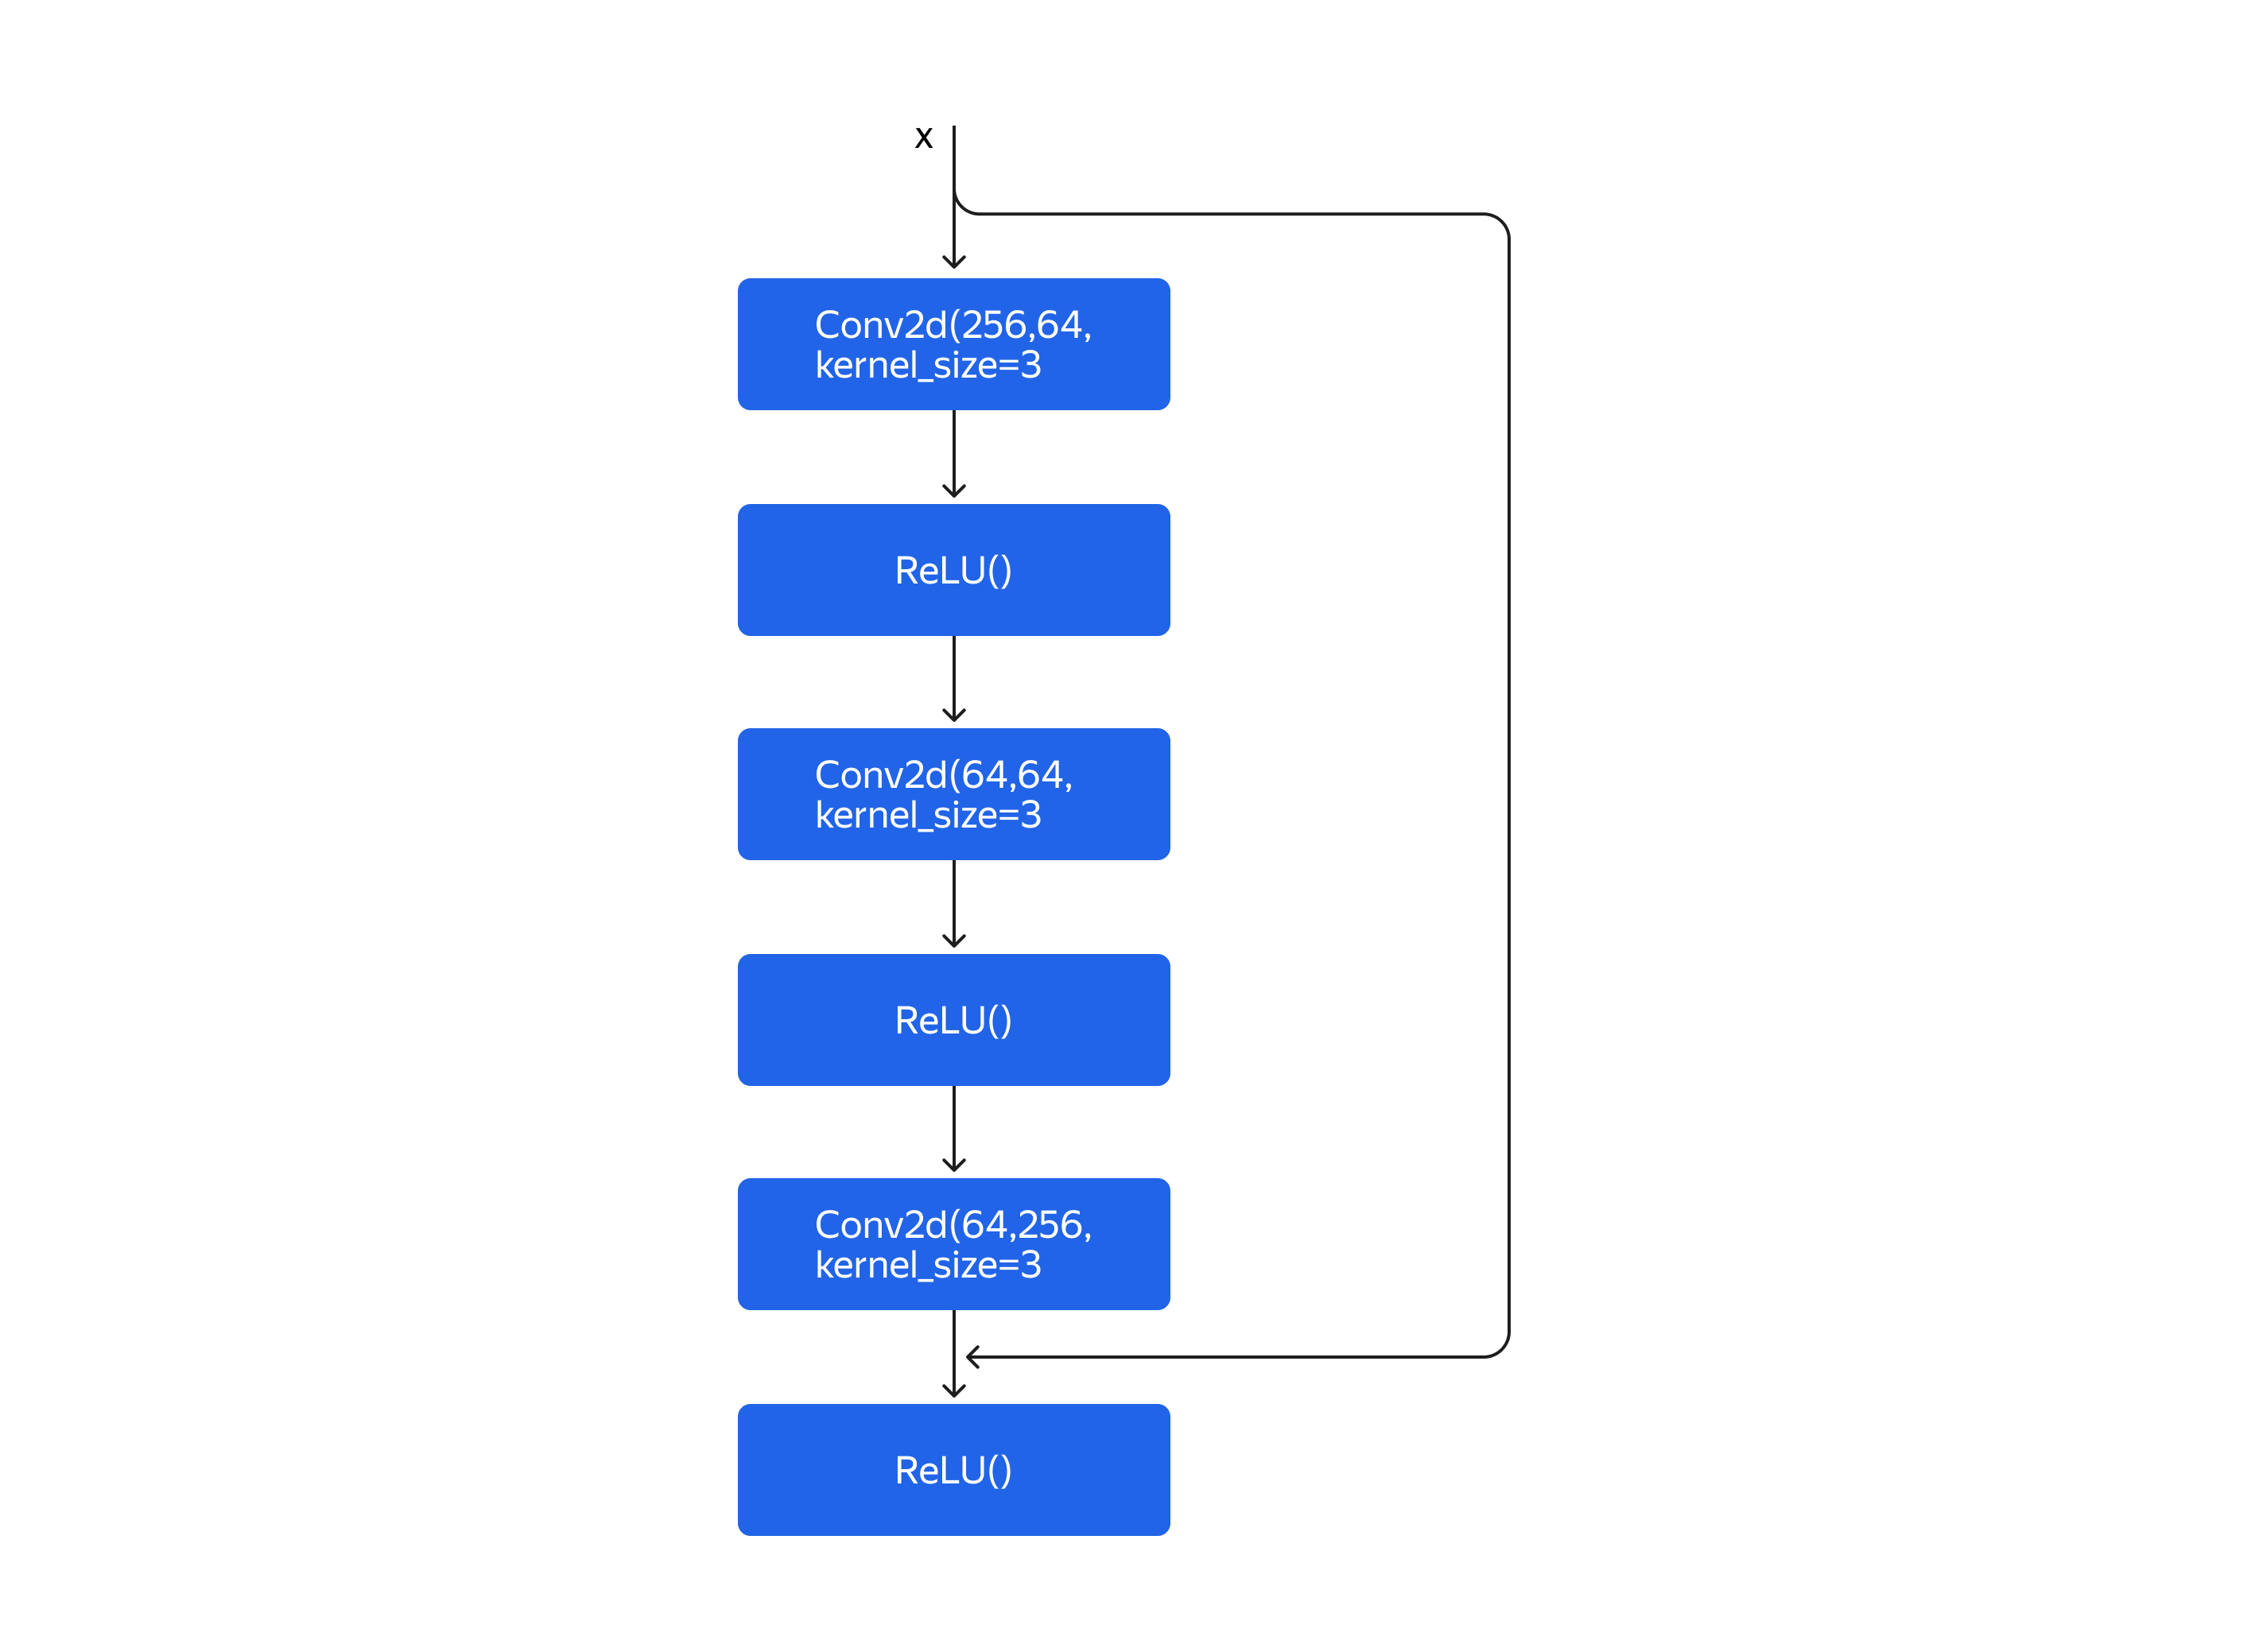

In [2]:
from PIL import Image
Image.open("pictures/image_1753348768.png")

In [5]:
import torch.nn as nn
from torch import Tensor

class ResidualBlock(nn.Module):
    def __init__(
        self,
        inputs: int,
        hidden: int,
        outputs: int,
        stride: int = 1,
    ) -> None:
        super().__init__()
        self.conv1 = nn.Conv2d(inputs,
                               hidden,
                               kernel_size=3,
                               stride=stride,
                               bias=False,
                               padding='same')
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(hidden,
                               hidden,
                               kernel_size=3,
                               stride=stride,
                               bias=False,
                               padding='same')
        self.conv3 = nn.Conv2d(hidden,
                               outputs,
                               kernel_size=3,
                               stride=stride,
                               bias=False,
                               padding='same')

    def forward(self, x: Tensor) -> Tensor:
        identity = x

        out = self.conv1(x)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.relu(out)

        out = self.conv3(out)

        out += identity
        out = self.relu(out)

        return out


print("Архитектура модели:", ResidualBlock(256, 64, 256))

Архитектура модели: ResidualBlock(
  (conv1): Conv2d(256, 64, kernel_size=(3, 3), stride=(1, 1), padding=same, bias=False)
  (relu): ReLU()
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=same, bias=False)
  (conv3): Conv2d(64, 256, kernel_size=(3, 3), stride=(1, 1), padding=same, bias=False)
)


## Задание 2
Реализуйте последовательность из трёх свёрточных слоёв:
1. Слой принимает тензор с глубиной 512, сжимает его глубину до 48.
1. Слой проводит над полученным компактным тензором свёртку 3х3.
1. Слой разжимает тензор после свёртки обратно до глубины 512.

Реализацию оформите в формате модели `nn.Sequential`, поместите её в переменную `model`.

Выполните задание локально, а затем сверьте решение с авторским, а вывод — с ожидаемым. 

In [8]:
import torch.nn as nn

model = nn.Sequential(
    nn.Conv2d(512, 48, 1, padding='same'),
    nn.Conv2d(48, 48, 3, padding='same'),
    nn.Conv2d(48, 512, 1, padding='same'),
)

print('Количество параметров:', sum(p.numel() for p in model.parameters())) 

Количество параметров: 70496


## Задание
Напишите класс BottleneckBlock для боттлнек-версии residual блока ResNet по схеме:

Выполните задание локально, а затем проведите самопроверку — сверьтесь с ожидаемым выводом и изучите авторское решение. 

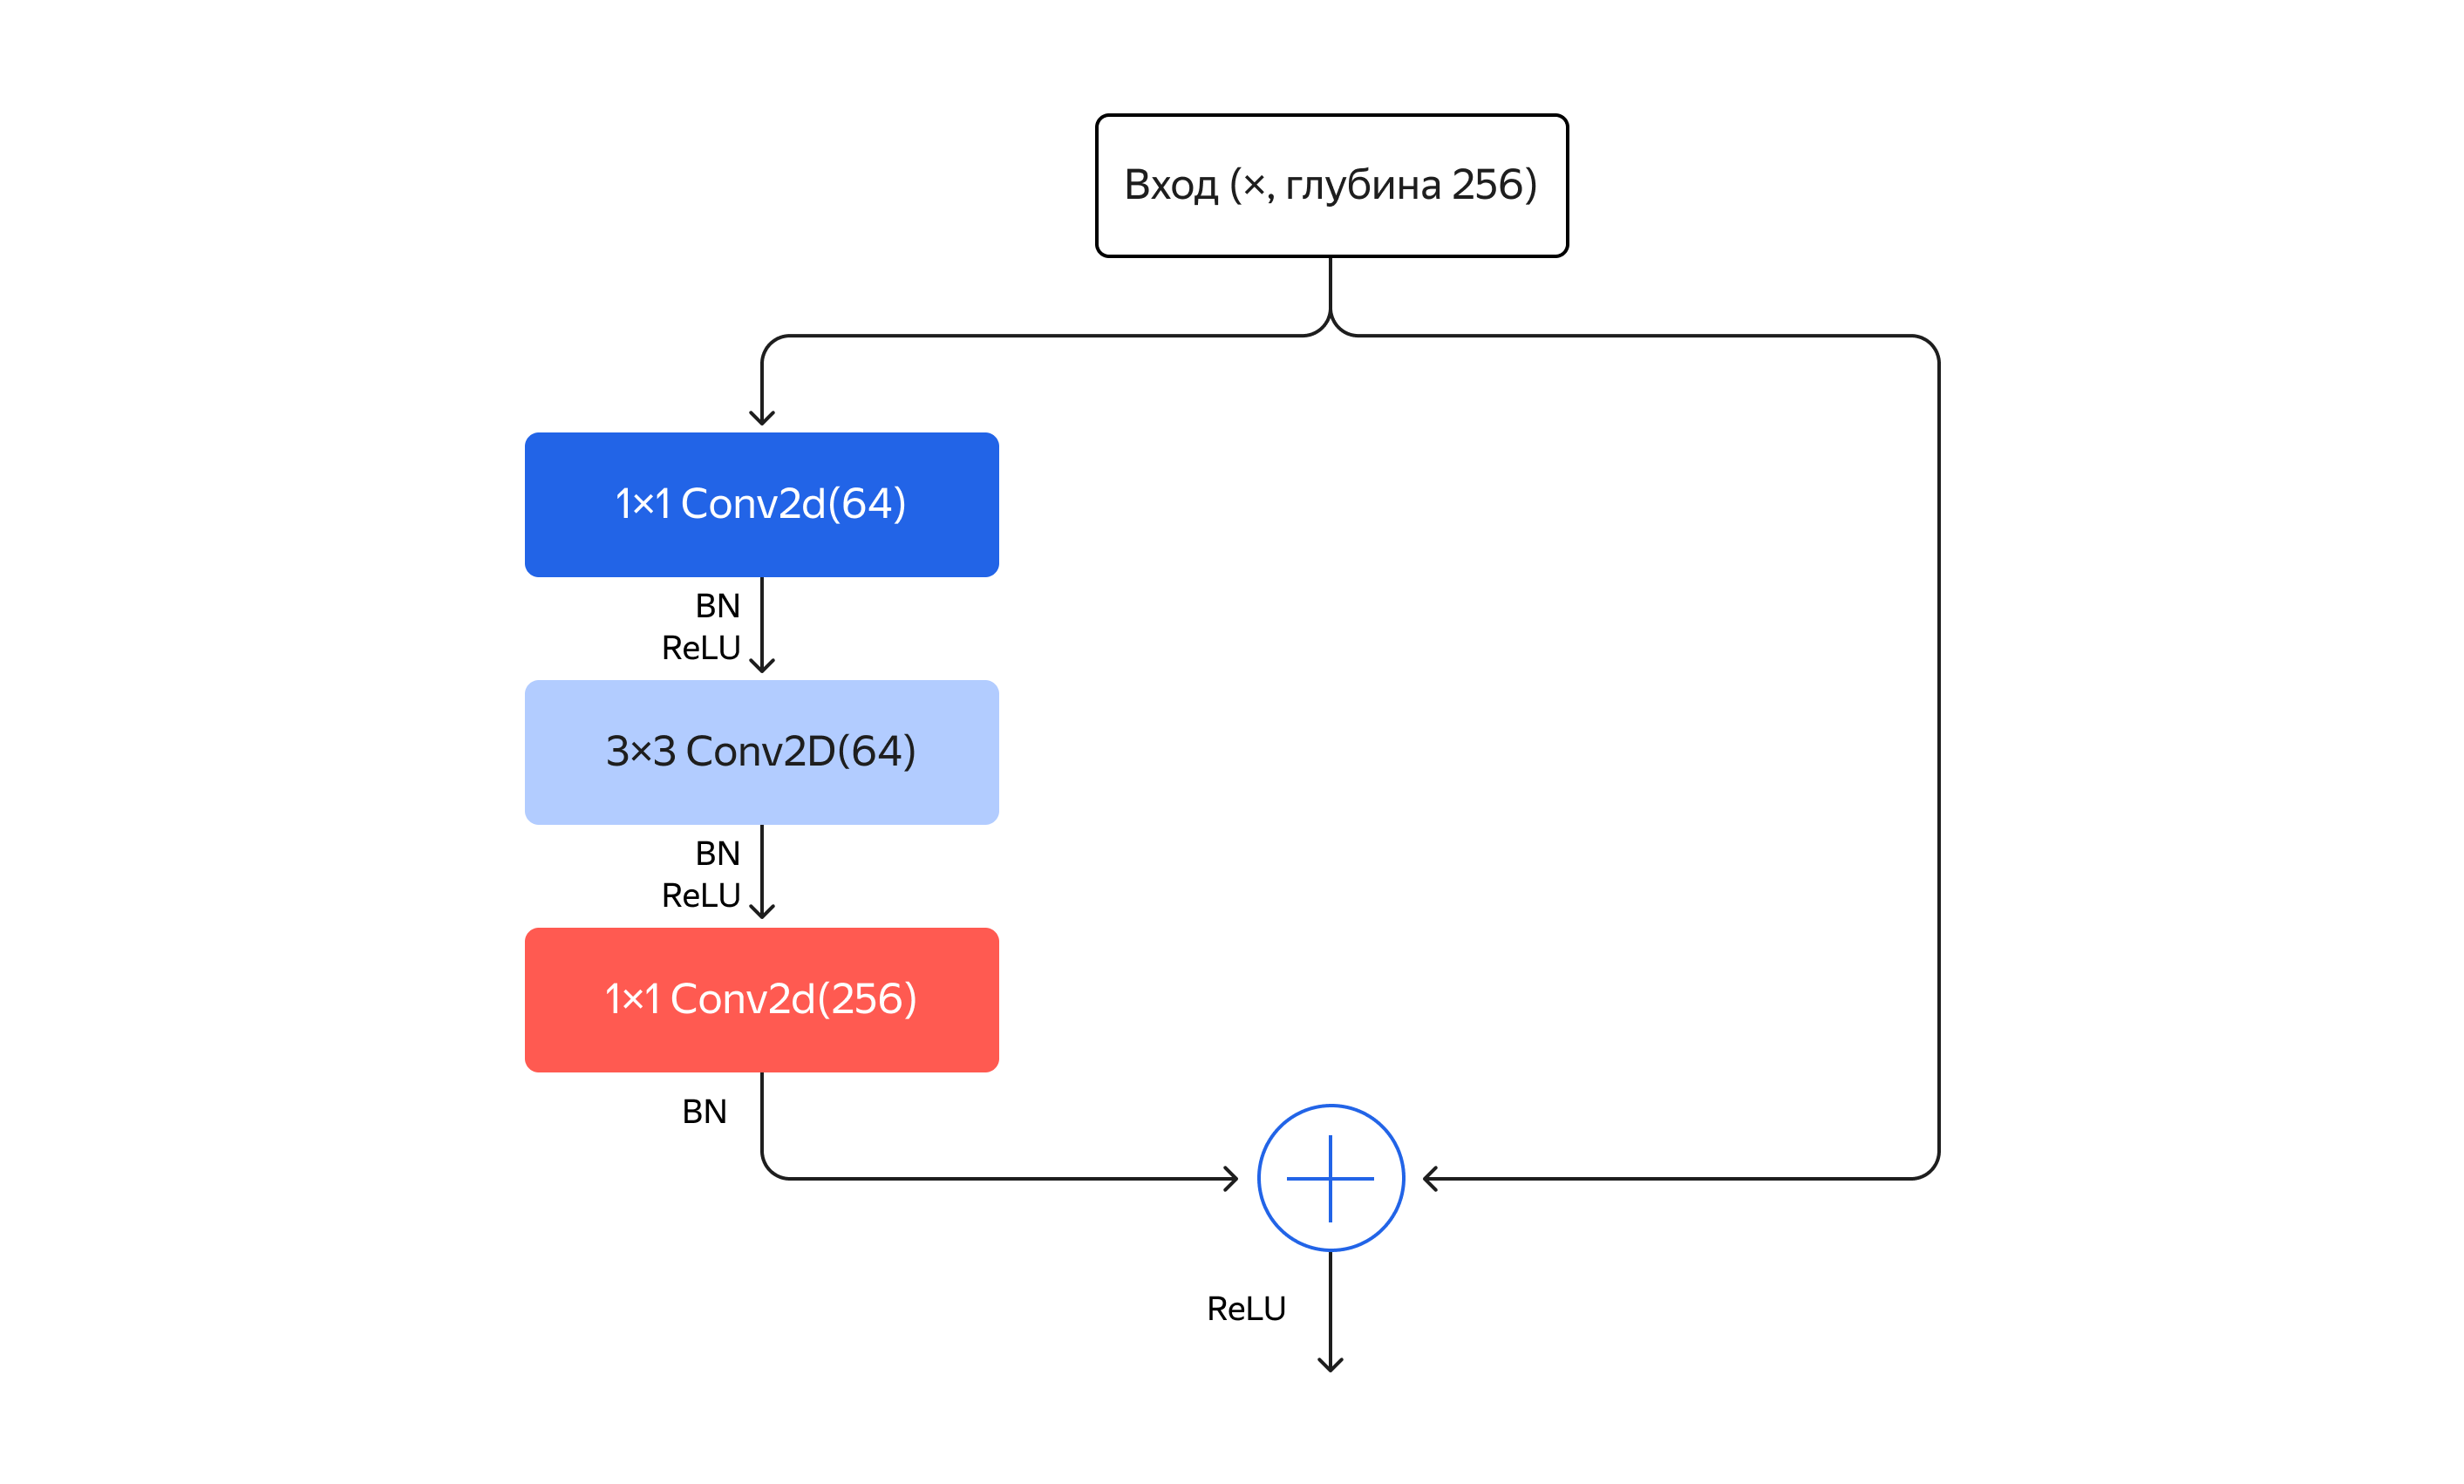

In [9]:
from PIL import Image
Image.open("pictures/image_1753349028.png")

In [14]:
import torch.nn as nn
from torch import Tensor

class BottleneckBlock(nn.Module):

    def __init__(
        self,
        inputs: int,
        hidden: int,
        outputs: int,
        stride: int = 1,
    ) -> None:
        super().__init__()
        self.conv1 = nn.Conv2d(inputs, hidden, 1, stride=stride, padding="same")
        self.conv2 = nn.Conv2d(hidden, hidden, 3, stride=stride, padding="same")
        self.conv3 = nn.Conv2d(hidden, outputs, 1, stride=stride, padding="same")
        self.relu = nn.ReLU()
        self.bn1 = nn.BatchNorm2d(hidden)
        self.bn2 = nn.BatchNorm2d(outputs)

    def forward(self, x: Tensor) -> Tensor:
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(x)
        out = self.bn2(out)

        out += identity
        out = self.relu(out)

        return out

model = BottleneckBlock(256, 64, 256)
print("Архитектура блока:", model)
print("Количество параметров:", sum(p.numel() for p in model.parameters()))

Архитектура блока: BottleneckBlock(
  (conv1): Conv2d(256, 64, kernel_size=(1, 1), stride=(1, 1), padding=same)
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), padding=same)
  (relu): ReLU()
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)
Количество параметров: 70656


## Задание 2
Используя наработки из прошлого задания, создайте полноценную архитектуру классификатора цветных изображений Classificator. 

Архитектура состоит из:
1. Входного свёрточного слоя: 7×7, 64 нейрона, страйд 2, пэддинг 3 + батч-нормализация + reLU.
1. Слоя макс-пулинга с окном 3×3, страйд 2, пэддинг 1.
1. Одного residual bottleneck блока (64 - 16 - 64).
1. Слоя глобального average пулинга.
1. Слоя Flatten, чтобы устранить лишние измерения.
1. Полносвязного слоя для классификации, который принимает 64 признака и классифицирует на n_classes классов.
1. Функции активации softmax на выходе.

Используйте параметр bias=False во всех свёрточных слоях.

Соблюдайте указанный порядок в архитектуре.  

Это ResNet-подобная архитектура, отличающаяся от оригинальной только количеством residual блоков и параметров внутри них.

In [23]:
import torch.nn as nn
from torch import Tensor
from torchsummary import summary # метод для распечатки архитектуры

class Classificator(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim,
        bottle_hidden_dim,
        n_classes: int,
    ) -> None:
        super().__init__()
        norm_layer = nn.BatchNorm2d
        
        # входная свёртка + батчнорм + релу
        self.conv1 = nn.Conv2d(input_dim, hidden_dim, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU()
        
        # слой макс-пулинга
        self.maxpool = nn.MaxPool2d(3, stride=2, padding=1)
        
        # слои для residual bottleneck блока
        self.bottle_conv1 = nn.Conv2d(hidden_dim, bottle_hidden_dim, 1, stride=1, padding="same", bias=False)
        self.bottle_conv2 = nn.Conv2d(bottle_hidden_dim, bottle_hidden_dim, 3, stride=1, padding="same", bias=False)
        self.bottle_conv3 = nn.Conv2d(bottle_hidden_dim, hidden_dim, 1, stride=1, padding="same", bias=False)
        self.bottle_bn1 = nn.BatchNorm2d(bottle_hidden_dim)
        self.bottle_bn2 = nn.BatchNorm2d(bottle_hidden_dim)
        self.bottle_bn3 = nn.BatchNorm2d(hidden_dim)

        # слой глобального пулинга
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        
        # Полносвязная часть в конце
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(64, n_classes)
        self.softmax = nn.Softmax(dim=1)


    def residual_bottleneck(self, x: Tensor) -> Tensor:
        identity = x
        out = self.bottle_conv1(x)
        out = self.bottle_bn1(out)
        out = self.relu(out)

        out = self.bottle_conv2(out)
        out = self.bottle_bn2(out)
        out = self.relu(out)

        out = self.bottle_conv3(out)
        out = self.bottle_bn3(out)

        out += identity
        out = self.relu(out)
        return out


    def forward(self, x: Tensor) -> Tensor:
        # входная свёртка + батчнорм + релу
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        # макс-пулинг
        out = self.maxpool(out)

        # residual bottleneck блок
        out = self.residual_bottleneck(out)
        
        # глобальный пулинг
        out = self.avgpool(out)
                
        # полносвязная часть для классификации
        out = self.flatten(out)
        out = self.fc(out)
        out = self.softmax(out)

        return out

# Проверка
model = Classificator(3, 64, 16, 10)
print("Количество параметров:", sum(p.numel() for p in model.parameters()))

# визуализация архитектуры при распознавании изображений размером 224х224х3
summary(model, input_size=(3, 224, 224),  device = 'cpu')

Количество параметров: 14730
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 16, 56, 56]           1,024
       BatchNorm2d-6           [-1, 16, 56, 56]              32
              ReLU-7           [-1, 16, 56, 56]               0
            Conv2d-8           [-1, 16, 56, 56]           2,304
       BatchNorm2d-9           [-1, 16, 56, 56]              32
             ReLU-10           [-1, 16, 56, 56]               0
           Conv2d-11           [-1, 64, 56, 56]           1,024
      BatchNorm2d-12           [-1, 64, 56, 56]             128
             ReLU-13           [-1, 64, 56, 56]               0
AdaptiveAv

## Задание
Создайте собственный блок DwConv для depth-wise separable свёртки 3×3. Он должен состоять из:
1. Слоя depth-wise-свёртки 3×3 + батч-нормализация + reLU.
2. Слоя pointwise-свёртки + батч-нормализация + reLU.

Выполните задание локально, а затем сверьтесь с ожидаемым выводом и авторским решением. 

In [25]:
from torch import nn
from torchsummary import summary

class DwConv(nn.Module):
    def __init__(self, inputs, outputs):
        super().__init__()
        self.conv1 = nn.Conv2d(inputs, inputs, 3, groups=inputs, padding="same")
        self.bn1 = nn.BatchNorm2d(inputs)
        self.relu = nn.ReLU()

        self.conv2 = nn.Conv2d(inputs, outputs, 1, padding="same")
        self.bn2 = nn.BatchNorm2d(outputs)
        

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(x)
        out = self.bn2(out)
        out = self.relu(out)
        return out
        
# Проверка  
block = DwConv(3, 64)
summary(block, input_size=(3, 224, 224),  device = 'cpu')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 3, 224, 224]              30
       BatchNorm2d-2          [-1, 3, 224, 224]               6
              ReLU-3          [-1, 3, 224, 224]               0
            Conv2d-4         [-1, 64, 224, 224]             256
       BatchNorm2d-5         [-1, 64, 224, 224]             128
              ReLU-6         [-1, 64, 224, 224]               0
Total params: 420
Trainable params: 420
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.57
Forward/backward pass size (MB): 76.95
Params size (MB): 0.00
Estimated Total Size (MB): 77.52
----------------------------------------------------------------


In [26]:
from torch import nn
from torchsummary import summary

class Conv(nn.Module):
    def __init__(self, inputs, outputs):
        super().__init__()
        norm_layer = nn.BatchNorm2d
        self.conv = nn.Conv2d(inputs, outputs, kernel_size=3, padding='same')
        self.relu = nn.ReLU()
        self.bn1 = norm_layer(outputs)

    def forward(self, x):
        out = self.conv(x)
        out = self.bn1(out)
        out = self.relu(out)
        return out

 
block = Conv(3, 64)
print("Количество параметров:", sum(p.numel() for p in block.parameters()))

summary(block, input_size=(3, 224, 224),  device = 'cpu')

Количество параметров: 1920
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
       BatchNorm2d-2         [-1, 64, 224, 224]             128
              ReLU-3         [-1, 64, 224, 224]               0
Total params: 1,920
Trainable params: 1,920
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.57
Forward/backward pass size (MB): 73.50
Params size (MB): 0.01
Estimated Total Size (MB): 74.08
----------------------------------------------------------------
